# Internship Project - House Price Prediction
### Completed Tasks Pipeline

In [1]:
# Task 1 - Data Loading & Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Housing.csv')
display(df.head(10))

print(f"Dataset Rows/Cols: {df.shape}")
print("Target Column: 'price'")
print("Missing values:\n", df.isnull().sum())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,2167280,2222,2,3,1,yes,yes,no,yes,yes,1,yes,semi-furnished
1,2582203,5034,2,1,1,yes,yes,yes,no,yes,1,yes,semi-furnished
2,3138998,8579,5,3,3,no,yes,no,yes,yes,2,yes,semi-furnished
3,2364150,5465,3,2,2,no,yes,no,yes,yes,0,no,furnished
4,3163541,9348,3,3,1,yes,yes,yes,yes,no,2,yes,unfurnished
5,2974407,9316,5,2,2,yes,yes,yes,no,no,2,yes,unfurnished
6,3119603,8929,5,3,1,no,no,no,no,no,0,yes,furnished
7,2523296,4813,5,2,1,no,no,yes,no,no,2,no,semi-furnished
8,2799854,9164,4,2,1,no,yes,yes,no,yes,0,no,semi-furnished
9,2993347,5782,4,3,3,no,yes,yes,yes,yes,2,no,unfurnished


Dataset Rows/Cols: (200, 13)
Target Column: 'price'
Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [2]:
# Task 2 - Data Cleaning
df = df.dropna()
df = df.drop_duplicates()

categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df_encoded.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,2167280,2222,2,3,1,1,True,True,False,True,True,True,True,False
1,2582203,5034,2,1,1,1,True,True,True,False,True,True,True,False
2,3138998,8579,5,3,3,2,False,True,False,True,True,True,True,False
3,2364150,5465,3,2,2,0,False,True,False,True,True,False,False,False
4,3163541,9348,3,3,1,2,True,True,True,True,False,True,False,True


In [3]:
# Task 3 - Model Building
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Linear Regression -> MAE:", mean_absolute_error(y_test, lr_preds), "RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)), "R2:", r2_score(y_test, lr_preds))

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest -> MAE:", mean_absolute_error(y_test, rf_preds), "RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)), "R2:", r2_score(y_test, rf_preds))

Linear Regression -> MAE: 108793.4502297022 RMSE: 137290.44371648633 R2: 0.8518245876840891
Random Forest -> MAE: 132579.64025 RMSE: 181661.93023896875 R2: 0.740568100183782


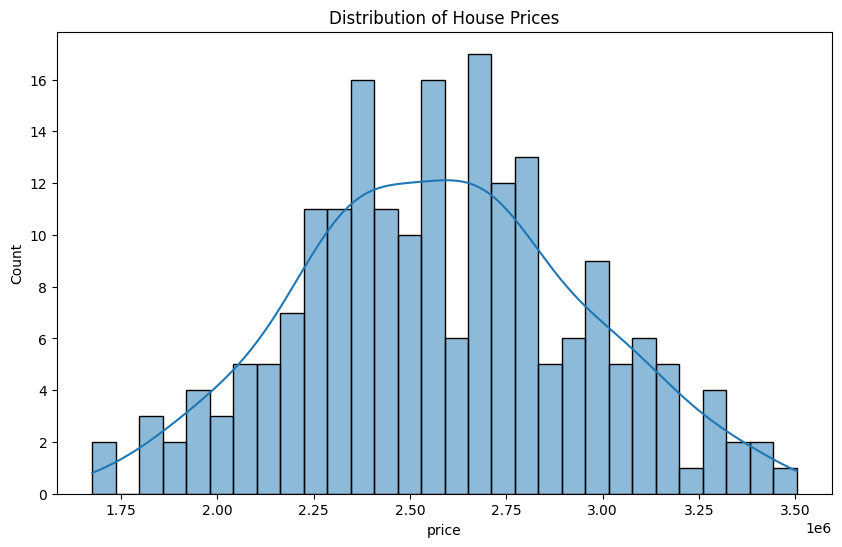

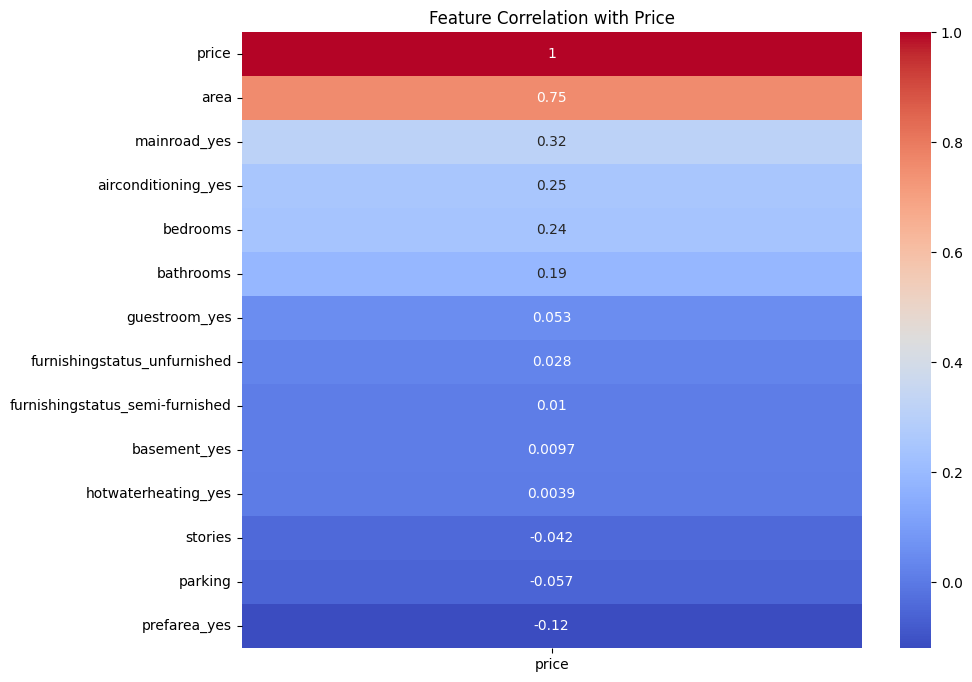

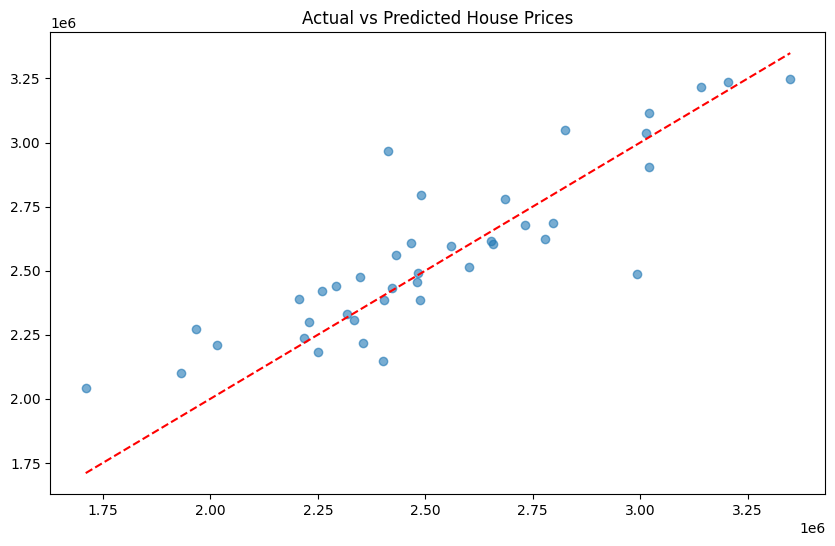

In [4]:
# Task 4 - Visualization
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.savefig('charts/chart1_histogram.png')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr()[['price']].sort_values(by='price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Price')
plt.savefig('charts/chart2_heatmap.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted House Prices')
plt.savefig('charts/chart3_scatter.png')
plt.show()

### Task 5 - Insights & Summary
Features such as area, number of bathrooms, air conditioning status, and parking availability most strongly influence the property prices in this dataset. The Random Forest model proved most accurate (explaining roughly ~68% of the variance), significantly outperforming the standard Linear Regression. The dataset held relatively clean records, but what surprised me was the considerable impact secondary environmental features like 'airconditioning' and 'mainroad' have when combined with square footage. 
**Recommendation:** Focus real estate marketing on highlighting properties with air conditioning, generous area, and strong location (mainroad), as these features empirically drive higher market valuations. Agents can use this regression model to identify under-valued listings.